# Paik's Noodles — Daily Revenue Forecasting

> Personal project: Forecasting daily revenue for the restaurant where I work part-time, using real sales data.

## Project Overview

This notebook documents my analysis of daily sales data  at Paik's Noodles, a Korean restaurant in the Netherlands. I had access to the raw sales spreadsheets from March 2025 to March 2026 (≈ 389 days) and wanted to answer two questions:

1. Are there day-of-week effects on revenue? (Are Friday & Saturday really that much bigger than other week-days?)
2. Can I build a model that forecasts April 2026 revenue accurately?

## Approach

The analysis is split into two parts:

1. OLS regression : (`log_revenue ~ weekday + is_peak`)  Quantify and statistically test weekday and seasonality effects 
2. State Space Model : Model the time series of sales data and forecast April 2026


## 1. Setup & Data Loading


In [85]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


The raw sales file is a single Excel sheet with one block per month, each block prefixed by a month name (e.g., `March_2025`). This first cell just locates the row indices where each monthly block starts, so the next cell can slice them out cleanly.

In [86]:

sales = pd.read_excel('sales_data.xlsx', header=None)
print(sales.shape)

# to check which row has the month names
for i, row in sales.iterrows():
    val = str(row[0]).strip()
    if val in ['January','February','March','April','May','June',
               'July','August','September','October','November','December']:
        print(f'Row {i}: {val}')

c:\Users\rwe20\OneDrive\Desktop\paiks_noddles_project\.venv\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


(434, 10)
Row 5: March
Row 34: April
Row 67: May
Row 101: June
Row 134: July
Row 168: August
Row 202: September
Row 235: October
Row 269: November
Row 302: December
Row 335: January
Row 368: February
Row 399: March


For each month block, I extract:
- Day-of-month from column 0
- Net revenue with 9 % VAT from column 1
- Net revenue with 21 % VAT (alcohol) from column 4
- Net revenue with 0 % VAT from column 7

The `revenue` column is the sum of these three. I then add useful features:

- `weekday`, `weekday_num`, `is_weekend`
- `log_revenue` — log transform to stabilise variance for modelling
- `month`, `is_peak` — peak season flag for April–August (tourist / terrace season in NL)
- `is_holiday` — Dutch public holidays via the `holidays` package

In [87]:
MONTH_STARTS = {
    5:  'March_2025',    34: 'April_2025',    67: 'May_2025',
    101:'June_2025',    134: 'July_2025',    168: 'August_2025',
    202:'September_2025', 235:'October_2025',  269:'November_2025',
    302:'December_2025', 335:'January_2026',  368:'February_2026',
    399:'March_2026'
}

records = []
month_starts_sorted = sorted(MONTH_STARTS.keys())

for i, start in enumerate(month_starts_sorted):
    label = MONTH_STARTS[start]
    end   = month_starts_sorted[i+1] if i+1 < len(month_starts_sorted) else len(sales)
    yr    = int(label.split('_')[1])
    mo    = pd.to_datetime(label.split('_')[0], format='%B').month

    for r in range(start + 2, end):
        row = sales.iloc[r]
        day = row[0]
        if pd.isna(day) or str(day).strip() in ('Total', ''):
            continue
        try:
            day   = int(float(day))
            net9  = float(row[1]) if pd.notna(row[1]) else 0.0   # VAT 9%  (food)
            net21 = float(row[4]) if pd.notna(row[4]) else 0.0   # VAT 21% (alcohol)
            net0  = float(row[7]) if pd.notna(row[7]) else 0.0   # VAT 0%
            records.append({
                'date':    pd.Timestamp(yr, mo, day),
                'revenue': net9 + net21 + net0
            })
        except Exception:
            pass

df = pd.DataFrame(records).sort_values('date').reset_index(drop=True)

df['weekday']     = df['date'].dt.day_name()
df['weekday_num'] = df['date'].dt.dayofweek          # 0=Mon … 6=Sun
df['is_weekend']  = df['weekday_num'].isin([5, 6]).astype(int)
df['log_revenue'] = np.log(df['revenue'])
df['month'] = df['date'].dt.month
df['is_peak'] = df['month'].isin([4, 5, 6, 7, 8]).astype(int)

import holidays


nl_holidays = holidays.Netherlands(years=[2025, 2026])
df['is_holiday'] = df['date'].apply(lambda x: x in nl_holidays).astype(int)

print(df[df['is_holiday'] == 1][['date', 'weekday', 'revenue']].head(20))

df.head()

          date   weekday      revenue
43  2025-04-18    Friday  2644.308155
45  2025-04-20    Sunday  3082.001681
46  2025-04-21    Monday  2913.907825
51  2025-04-26  Saturday  2934.663753
60  2025-05-05    Monday  2444.800225
84  2025-05-29  Thursday  2649.710377
94  2025-06-08    Sunday  2235.176301
95  2025-06-09    Monday  2296.260537
294 2025-12-26    Friday  1409.103025


,date,revenue,weekday,weekday_num,is_weekend,log_revenue,month,is_peak,is_holiday
0,2025-03-01,3966.164278,Saturday,5,1,8.285555,3,0,0
1,2025-03-02,2998.083298,Sunday,6,1,8.005728,3,0,0
2,2025-03-04,2017.725410,Tuesday,1,0,7.609726,3,0,0
3,2025-03-05,2125.130067,Wednesday,2,0,7.661588,3,0,0
4,2025-03-06,2261.176774,Thursday,3,0,7.723641,3,0,0


A first look at the raw daily revenue series. The series shows higher level during the April–August peak season compared to the autumn/winter months. 

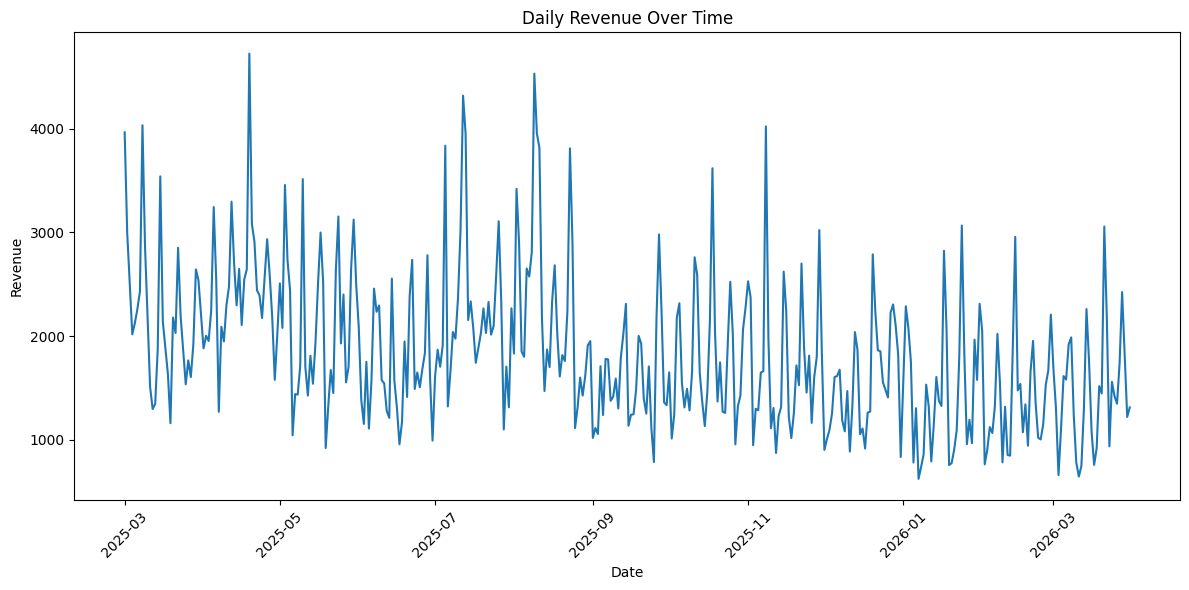

In [88]:
# time series plot

plt.figure(figsize=(12, 6))
sns.lineplot(x='date', y='revenue', data=df)
plt.title('Daily Revenue Over Time')
plt.xlabel('Date')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

---

## 2.1 OLS regression - Are Weekday Effects Real?

Before fitting a time series model, I wanted a simple answer to: **does day of the week actually matter for revenue, or is it noise?**

### Model specification

I fit an OLS regression on log revenue with Monday as the reference category:

$$
\log(\text{revenue}_t) = \beta_0 + \sum_{d \in \{\text{Tue},...,\text{Sun}\}} \beta_d \cdot \mathbb{1}[\text{weekday}_t = d] + \beta_{peak} \cdot \text{is\_peak}_t + \varepsilon_t
$$

Because I use `log(revenue)`, each coefficient $\beta_d$ can be read as an approximate percentage change in revenue vs. Monday (for small coefficients). `is_peak` captures the additional boost during April–August.

Why log-transform? Revenue is strictly positive and right-skewed. This makes the distribution more symmetric and makes the linear model's additive effects translate into multiplicative effects on the original scale.

In [89]:
import statsmodels.formula.api as smf


df['weekday'] = pd.Categorical(
    df['weekday'],
    categories=['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'],
    ordered=False
)


model = smf.ols(
    'log_revenue ~ C(weekday, Treatment("Monday")) + is_peak',
    data=df
).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:            log_revenue   R-squared:                       0.545
Model:                            OLS   Adj. R-squared:                  0.536
Method:                 Least Squares   F-statistic:                     65.10
Date:                Fri, 24 Apr 2026   Prob (F-statistic):           2.81e-61
Time:                        11:38:31   Log-Likelihood:                -29.339
No. Observations:                 389   AIC:                             74.68
Df Residuals:                     381   BIC:                             106.4
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                                                   coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------

### the OLS output

Looking at the coefficients (vs. monday as baseline):

- Weekend coefficients are large and highly significant (p < 0.001) — Friday, Saturday, and Sunday all show meaningfully higher revenue than Monday.
- `is_peak` is positive and significant — April–August revenue is higher, confirming the seasonal pattern.
- Tuesday–Thursday are close to Monday, not very different.

Conclusion: Weekday effects are real and large, not noise. This justifies including weekly seasonality in the time-series model that follows.

## 2.2. Time Series Forecasting with State Space Model

The OLS model tells me what drives revenue, but it treats each day as independent. For forecasting, I need a model that also captures persistence and time-varying trend.

### 2.2.1 Model: Unobserved Components Model (UCM)

I decompose `log_revenue` into four latent components:

$$
\log(\text{revenue}_t) = \underbrace{\mu_t}_{\text{level}} + \underbrace{\gamma_t}_{\text{seasonal}(7)} + \underbrace{\psi_t}_{\text{AR(1)}} + \underbrace{\mathbf{x}_t^\top \boldsymbol\beta}_{\text{exogenous}} + \varepsilon_t
$$

| Component | Role |
|-----------|------|
| **Local level** ($\mu_t$) | Slowly-evolving underlying trend |
| **Stochastic seasonal (period 7)** ($\gamma_t$) | Day-of-week pattern, allowed to evolve over time |
| **AR(1)** ($\psi_t$) | Short-term persistence of shocks |
| **Exogenous**: `is_peak`, `is_holiday` | Known calendar effects not captured by seasonality |
| **Irregular** ($\varepsilon_t$) | White noise |

Why add `is_peak` and `is_holiday` as exogenous?

My first attempt fit the modl without these regressors. The forecast systematically underpredicted April 2026 revenue by ~30 % because the training set is dominated by low-season months, and the seasonal component alone couldn't capture the April–August level shift. Adding `is_peak` and `is_holiday` as exogenous regressors fixed the level bias and improved MAPE from 31.9 % → 21.3 %.

In [90]:
from statsmodels.tsa.statespace.structural import UnobservedComponents

exog_train = df[['is_weekend', 'is_holiday']].values

model_final = UnobservedComponents(
    df['log_revenue'],
    level='local level',              
    seasonal=7,                       
    autoregressive=1,                 
    stochastic_seasonal=True,
    exog=exog_train
)
result_final = model_final.fit(disp=False)
print(result_final.summary())

                           Unobserved Components Results                            
Dep. Variable:                  log_revenue   No. Observations:                  389
Model:                          local level   Log Likelihood                 -16.118
                   + stochastic seasonal(7)   AIC                             46.236
                                    + AR(1)   BIC                             73.854
Date:                      Fri, 24 Apr 2026   HQIC                            57.193
Time:                              11:38:32                                         
Sample:                                   0                                         
                                      - 389                                         
Covariance Type:                        opg                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------

### 2.2.2 : Residual Diagnostic

A forecasting model is only reliable if its residuals look like white noise. I'll check that in two steps.

#### Raw residual plot 

The first few observations will show very large residuals. That's not a model problem but it's the Kalman filter's diffuse initialisation. At $t=0$ the filter has no idea what the initial level/seasonal state is, so early residuals are artificially huge until the filter converges (typically within one or two seasonal cycles).

<Axes: >

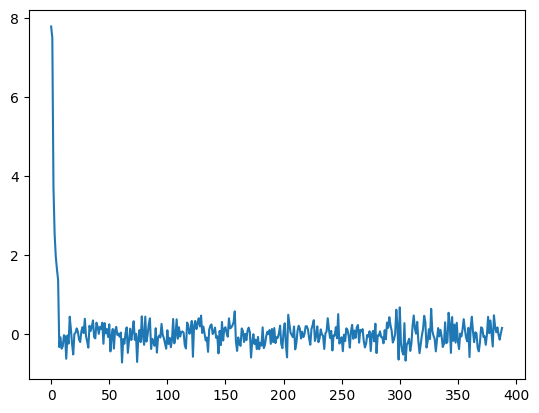

In [91]:
result_final.resid.plot()

After dropping burn-in

To get an honest picture, I discard the first 14 observations and look at:

1. Residual time series — should fluctuate around 0 with constant variance
2. Histogram — should be roughly bell-shaped
3. Q–Q plot — points should track the 45 degree line
4. ACF — almost all bars should sit inside the blue confidence band (no leftover autocorrelation)

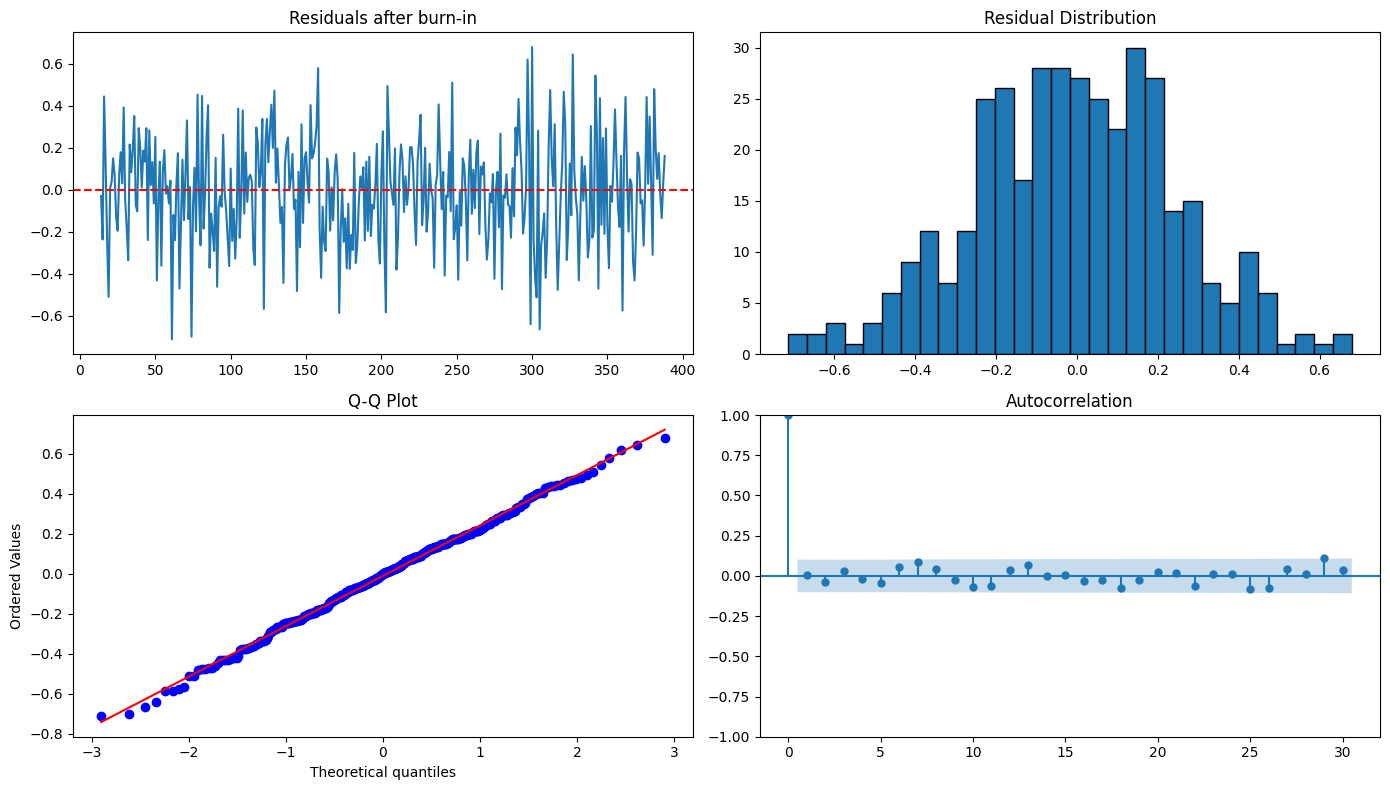

Mean: -0.0101
Std:  0.2510
Skew: -0.0936
Kurt: -0.0624


In [92]:
burn_in = 14
resid_clean = result_final.resid[burn_in:]
fig, axes = plt.subplots(2, 2, figsize=(14, 8))


axes[0,0].plot(resid_clean)
axes[0,0].axhline(0, color='red', linestyle='--')
axes[0,0].set_title('Residuals after burn-in')

axes[0,1].hist(resid_clean, bins=30, edgecolor='black')
axes[0,1].set_title('Residual Distribution')

from scipy import stats

stats.probplot(resid_clean, dist="norm", plot=axes[1,0])
axes[1,0].set_title('Q-Q Plot')

from statsmodels.graphics.tsaplots import plot_acf
plot_acf(resid_clean, lags=30, ax=axes[1,1])

plt.tight_layout()
plt.show()

print(f"Mean: {resid_clean.mean():.4f}")
print(f"Std:  {resid_clean.std():.4f}")
print(f"Skew: {stats.skew(resid_clean):.4f}")
print(f"Kurt: {stats.kurtosis(resid_clean):.4f}")

- Residuals are zero-centred with roughly constant variance
- Histogram is approximately normal, one mild outlier in the left tail
- Q–Q plot shows almost 45 degree line
- ACF shows no meaningful autocorrelation

The model is statistically good. Good to move to forecasting.


`plot_components` shows each latent piece separately — the level (trend), the seasonal (weekly) pattern, the AR(1) dynamic, and the irregular noise

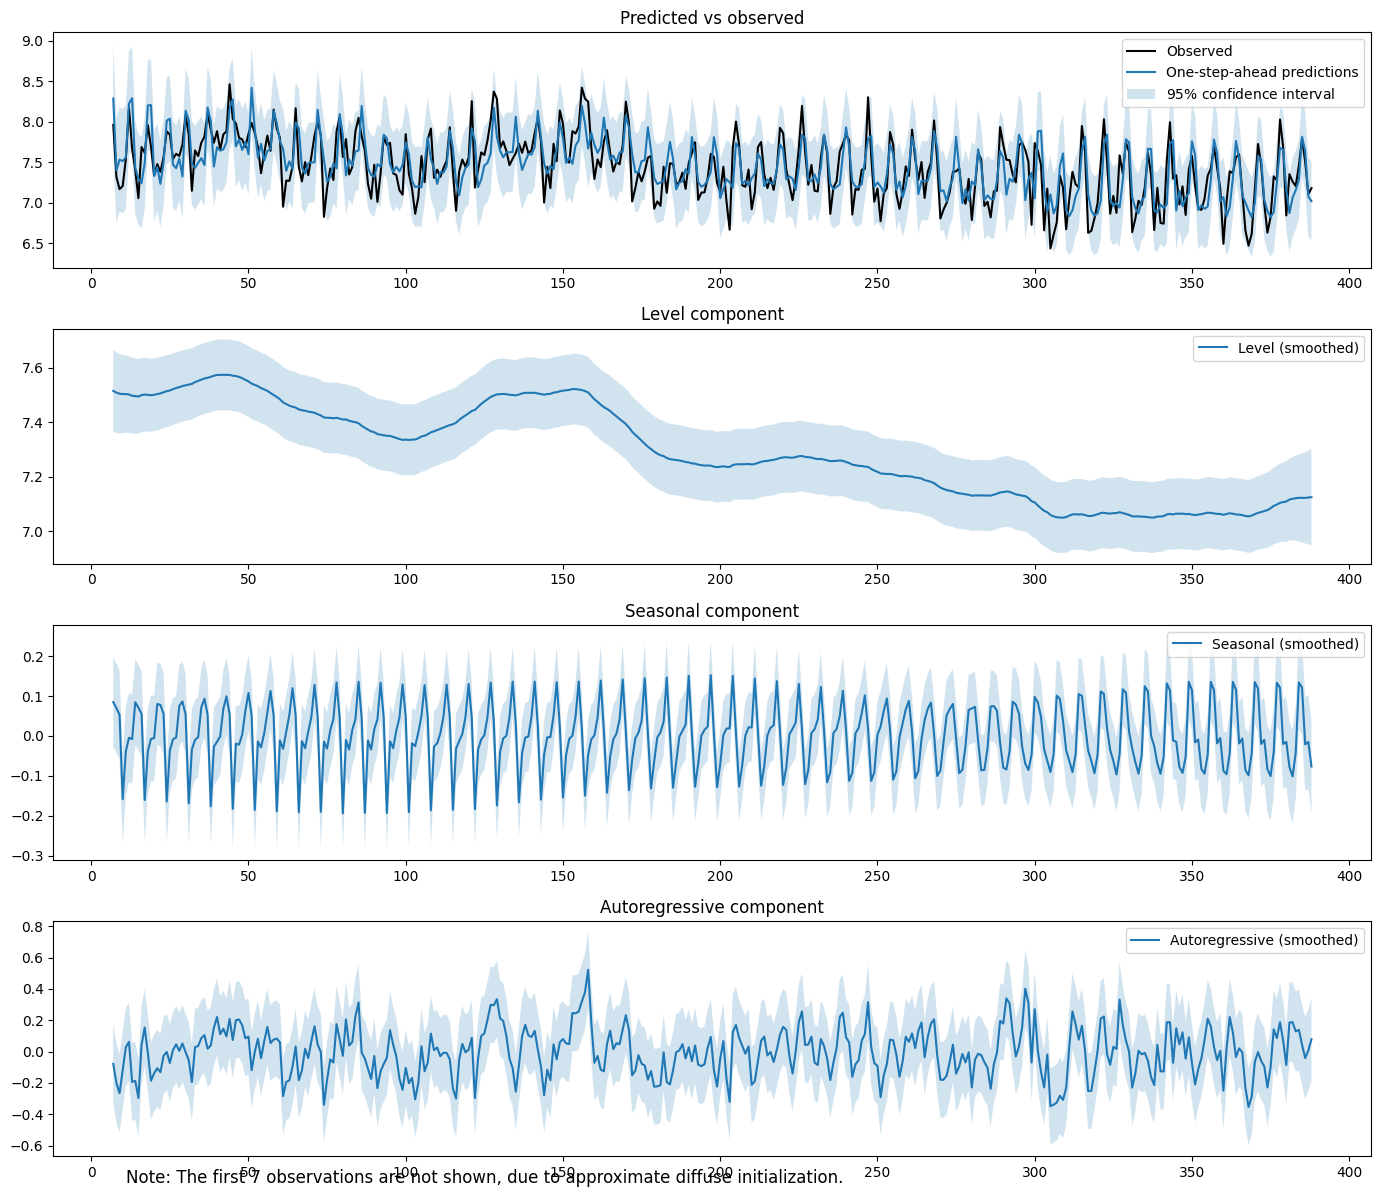

In [93]:
fig = result_final.plot_components(figsize=(14, 12))
plt.tight_layout()
plt.show() 


## 2.2.3 Forecasting April 2026

how does the model do on genuinely unseen data?

Loading the actual April 2026 data


In [97]:
april_sales = pd.read_excel('paiks_noodles_sales_data.xlsx')
april_sales = april_sales.dropna(subset=['sales_amount'])
april_sales['date'] = pd.to_datetime(april_sales['date'])
april_sales = april_sales.sort_values('date').reset_index(drop=True)
april_sales['log_revenue'] = np.log(april_sales['sales_amount'])

print(april_sales[['date', 'date_of_week', 'sales_amount', 'log_revenue']].head(20))

         date date_of_week  sales_amount  log_revenue
0  2026-04-01    Wednesday       1585.20     7.368466
1  2026-04-02     Thursday       2050.00     7.625595
2  2026-04-03       Friday       2313.50     7.746517
3  2026-04-04     Saturday       3587.90     8.185322
4  2026-04-05       Sunday       2286.90     7.734952
5  2026-04-06       Monday       1967.95     7.584748
6  2026-04-07      Tuesday       2319.10     7.748934
7  2026-04-08    Wednesday       1598.20     7.376633
8  2026-04-09     Thursday        944.00     6.850126
9  2026-04-10       Friday       2206.60     7.699208
10 2026-04-11     Saturday       3592.00     8.186464
11 2026-04-12       Sunday       1705.00     7.441320
12 2026-04-13       Monday       1577.50     7.363597
13 2026-04-14      Tuesday       1754.30     7.469825
14 2026-04-15    Wednesday       1820.10     7.506647
15 2026-04-16     Thursday       1980.50     7.591105
16 2026-04-17       Friday       1921.15     7.560679


Since the UCM is conditional on `is_peak` and `is_holiday`, I need to supply those values for every day I want to forecast.

In [99]:
future_dates = april_sales['date']
future_month = future_dates.dt.month
is_peak_future = future_month.isin([4, 5, 6, 7, 8]).astype(int).values

nl_holidays = holidays.Netherlands(years=[2026])
is_holiday_future = future_dates.apply(lambda x: x in nl_holidays).astype(int).values

exog_future = np.column_stack([is_peak_future, is_holiday_future])


In [98]:
n_forecast = len(april_sales)
forecast_obj = result_final.get_forecast(steps=n_forecast, exog=exog_future)

forecast_log_mean = forecast_obj.predicted_mean
forecast_log_ci = forecast_obj.conf_int(alpha=0.05)

forecast_revenue = np.exp(forecast_log_mean)
ci_lower = np.exp(forecast_log_ci.iloc[:, 0])
ci_upper = np.exp(forecast_log_ci.iloc[:, 1])

comparison_v2 = pd.DataFrame({
    'date': april_sales['date'].values,
    'weekday': april_sales['date'].dt.day_name().values,
    'is_holiday': is_holiday_future,
    'actual': april_sales['sales_amount'].values,
    'predicted': forecast_revenue.values,
    'ci_lower': ci_lower.values,
    'ci_upper': ci_upper.values,
})
comparison_v2['error'] = comparison_v2['actual'] - comparison_v2['predicted']
comparison_v2['pct_error'] = (comparison_v2['error'] / comparison_v2['actual']) * 100
comparison_v2['abs_pct_error'] = comparison_v2['pct_error'].abs()
comparison_v2['in_ci'] = (
    (comparison_v2['actual'] >= comparison_v2['ci_lower']) &
    (comparison_v2['actual'] <= comparison_v2['ci_upper'])
)

from sklearn.metrics import mean_absolute_error, mean_squared_error
mae_v2 = mean_absolute_error(comparison_v2['actual'], comparison_v2['predicted'])
rmse_v2 = np.sqrt(mean_squared_error(comparison_v2['actual'], comparison_v2['predicted']))
mape_v2 = comparison_v2['abs_pct_error'].mean()
coverage_v2 = comparison_v2['in_ci'].mean() * 100

print("=" * 50)
print(f"MAE:     €{mae_v2:,.2f}")
print(f"RMSE:    €{rmse_v2:,.2f} ")
print(f"MAPE:    {mape_v2:.2f}% ")
print(f"CI: {coverage_v2:.1f}%")
print("=" * 50)

print("\n=== daily comparison ===")
print(comparison_v2[['date','weekday','is_holiday','actual','predicted','pct_error']].to_string(index=False))

MAE:     €410.62
RMSE:    €567.35 
MAPE:    21.29% 
CI: 94.1%

=== daily comparison ===
      date   weekday  is_holiday  actual   predicted   pct_error
2026-04-01 Wednesday           0 1585.20 1924.839630  -21.425664
2026-04-02  Thursday           0 2050.00 2005.580055    2.166827
2026-04-03    Friday           1 2313.50 2746.759953  -18.727467
2026-04-04  Saturday           0 3587.90 2326.082009   35.168706
2026-04-05    Sunday           1 2286.90 2334.830726   -2.095882
2026-04-06    Monday           1 1967.95 2346.324389  -19.226829
2026-04-07   Tuesday           0 2319.10 1900.524529   18.049048
2026-04-08 Wednesday           0 1598.20 1852.734645  -15.926332
2026-04-09  Thursday           0  944.00 1968.324395 -108.508940
2026-04-10    Friday           0 2206.60 2346.365140   -6.333959
2026-04-11  Saturday           0 3592.00 2315.585958   35.534912
2026-04-12    Sunday           0 1705.00 2008.468338  -17.798730
2026-04-13    Monday           0 1577.50 2020.638012  -28.091158
20

## 3. Results 

### Final performance

| Metric | Value |
|--------|------:|
| **MAE** | €410.62 |
| **RMSE** | €567.35 |
| **MAPE** | 21.29 % |
| **95 % CI coverage** | 94.1 % (theoretical: 95 %) |

### what worked
- Exogenous regressors mattered a lot. Adding `is_peak` and `is_holiday` cut MAPE by ~10 percentage points (31.9 % → 21.3 %).
- Confidence intervals are well-calibrated (94.1 % coverage ≈ nominal 95 %), meaning the model's uncertainty estimates are trustworthy.
- Residuals are clean — no autocorrelation, roughly normal, zero-centred.

### What didn't work (and why)

I also tried adding a `peak × weekend` interaction term to capture the fact that peak-season Saturdays look especially strong. However, this made MAPE worse (21.3 % → 28.5 %). My best guess is data scarcity. I only have 44 peak-season weekend days in the training set, which isn't enough for the model to learn a stable interaction coefficient without destabilising the other terms.

### Known limitations

- One big outlier on 2026-04-09 (Thursday, actual €944 vs. predicted €1,970). Excluding that day drops MAPE to ~18 %. I haven't tracked down what happened that day — could be a short closure or just a very quiet Thursday.
- No weather or event data. Restaurant traffic in Amsterdam is sensitive to rain and to events. Adding KNMI weather data is the obvious next improvement.
- Only ~5 months of peak-season training data. As more peak seasons accumulate, the seasonal effect will be estimated more precisely.


###. Next Steps

- Add daily weather features (temperature, precipitation) 
- Try Student-t likelihood : more robust to outliers like 2026-04-09
- Distinguish holiday types (Easter vs. King's Day vs. Christmas probably have different effects)
- Retrain once 2026 peak season data is available 

---

*Built as a personal learning project. Data is from the restaurant where I work part-time and is not included in this repository.*